# Intelligent University Observatory


## 1. Install Dependencies

In [49]:
!pip install pandas numpy scikit-learn sentence-transformers networkx matplotlib requests

## 2. Imports

In [50]:
import pandas as pd
import numpy as np
import requests
import sqlite3
import networkx as nx
import matplotlib.pyplot as plt

from collections import defaultdict
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

## 3. Observer Agent (Real Data Collection)

In [51]:
class AgentObserver:
    def fetch_papers(self, query="machine learning", limit=100):
        url = "https://api.semanticscholar.org/graph/v1/paper/search"
        params = {
            "query": query,
            "limit": limit,
            "fields": "title,authors,year,citationCount,fieldsOfStudy"
        }
        response = requests.get(url, params=params)
        data = response.json()

        papers = []
        for p in data.get("data", []):
            papers.append({
                "title": p.get("title"),
                "year": p.get("year"),
                "citations": p.get("citationCount"),
                "authors": [a["name"] for a in p.get("authors", [])],
                "fields": p.get("fieldsOfStudy")
            })
        return pd.DataFrame(papers)

## 4. Build Researcher Dataset

In [52]:
def build_researchers(papers_df):
    from collections import defaultdict

    researchers = defaultdict(lambda: {
        "name": "",
        "publications_count": 0,
        "citations": 0,
        "expertise": []
    })

    for _, row in papers_df.iterrows():
        for author in row["authors"]:
            researchers[author]["name"] = author
            researchers[author]["publications_count"] += 1
            researchers[author]["citations"] += row.get("citations", 0) or 0

            if row.get("fields"):
                researchers[author]["expertise"].extend(row["fields"])

    # 🔥 Build full dataframe properly
    df = pd.DataFrame([
        {
            "name": v["name"],
            "publications_count": v["publications_count"],
            "citations": v["citations"],
            "expertise": ", ".join(set(v["expertise"])) if v["expertise"] else "AI"
        }
        for v in researchers.values()
    ])

    # 🔥 IMPORTANT: ensure all columns exist
    for col in ["name", "publications_count", "citations", "expertise"]:
        if col not in df.columns:
            df[col] = 0

    return df[df["publications_count"] > 1]

## 5. Profiling Agent

In [53]:
class AgentProfiler:
    def run(self, df):
        print("Top Researchers by Citations:")
        display(df.sort_values(by="citations", ascending=False).head(10))

## 6. Database

In [54]:
conn = sqlite3.connect("research.db")

def save_database(researchers, papers):
    import sqlite3

    conn = sqlite3.connect("research.db")

    papers_fixed = papers.copy()

    # --- SAFE FIX: handle missing columns ---
    if "authors" in papers_fixed.columns:
        papers_fixed["authors"] = papers_fixed["authors"].apply(
            lambda x: ", ".join(x) if isinstance(x, list) else str(x)
        )
    else:
        papers_fixed["authors"] = "Unknown"

    if "fields" in papers_fixed.columns:
        papers_fixed["fields"] = papers_fixed["fields"].apply(
            lambda x: ", ".join(x) if isinstance(x, list) else str(x)
        )
    else:
        papers_fixed["fields"] = "Unknown"

    # --- Save tables ---
    researchers.to_sql("Researchers", conn, if_exists="replace", index=False)
    papers_fixed.to_sql("Publications", conn, if_exists="replace", index=False)

    labs = pd.DataFrame({
        "lab_id": range(len(researchers)),
        "lab_name": ["AI Lab"] * len(researchers),
        "researcher_name": researchers["name"]
    })

    labs.to_sql("Labs", conn, if_exists="replace", index=False)

    print("Database saved successfully")

## 7. Expertise Matching

In [55]:
class AgentExpertiseMatcher:
    def run(self, df):
        model = SentenceTransformer('all-MiniLM-L6-v2')
        embeddings = model.encode(df["expertise"].tolist())
        sim = cosine_similarity(embeddings)
        return embeddings, sim

## 8. Clustering

In [56]:
class AgentCluster:
    def run(self, df, embeddings):
        kmeans = KMeans(n_clusters=5, random_state=42)
        df["cluster"] = kmeans.fit_predict(embeddings)
        return df

## 9. Collaboration Recommendation

In [57]:
def compute_score(r1, r2, sim):
    impact = (r1["citations"] + r2["citations"]) / 20000

    pub1 = r1.get("publications_count", 0)
    pub2 = r2.get("publications_count", 0)

    productivity = (pub1 + pub2) / 100

    complementarity = 1 - sim

    return sim*0.5 + impact*0.3 + productivity*0.2 + complementarity*0.2

class AgentCollabAdvisor:
    def run(self, df, sim):
        results = []
        for i in range(len(df)):
            for j in range(i+1, len(df)):
                r1 = df.iloc[i]
                r2 = df.iloc[j]
                score = compute_score(r1, r2, sim[i][j])
                results.append({
                    "r1": r1["name"],
                    "r2": r2["name"],
                    "score": score
                })
        return pd.DataFrame(results).sort_values(by="score", ascending=False)

## 10. Negotiation (Game Theory)

In [58]:
class AgentNegotiator:
    def run(self, df):
        decisions = []
        for _, row in df.iterrows():
            benefit = row["score"]
            cost = np.random.uniform(0.2, 0.5)
            payoff = benefit - cost
            decisions.append("ACCEPTED" if payoff > 0.3 else "REJECTED")
        df["decision"] = decisions
        return df

## 11. Visualization

In [59]:
def plot_network(df):
    G = nx.Graph()
    for _, row in df.head(30).iterrows():
        if row["decision"] == "ACCEPTED":
            G.add_edge(row["r1"], row["r2"], weight=row["score"])

    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_size=2000, font_size=7)
    plt.show()

## 12. Run Full Pipeline

Columns: Index(['name', 'publications_count', 'citations', 'expertise'], dtype='object')
Top Researchers by Citations:


,name,publications_count,citations,expertise
250,Dzmitry Bahdanau,2,55374,"Computer Science, Mathematics"
247,Kyunghyun Cho,2,55374,"Computer Science, Mathematics"
253,Yoshua Bengio,2,55374,"Computer Science, Mathematics"
26,S. Ghemawat,2,31191,Computer Science
23,Andy Davis,2,31191,Computer Science
24,J. Dean,2,31191,Computer Science
25,M. Devin,2,31191,Computer Science
28,M. Isard,2,31191,Computer Science
19,Martín Abadi,2,31191,Computer Science
20,P. Barham,2,31191,Computer Science


Database saved successfully


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Top Collaborations:


,r1,r2,score
350,Dzmitry Bahdanau,Yoshua Bengio,2.169220
349,Kyunghyun Cho,Yoshua Bengio,2.169220
348,Kyunghyun Cho,Dzmitry Bahdanau,2.169220
257,R. Monga,Kyunghyun Cho,1.772392
258,R. Monga,Dzmitry Bahdanau,1.772392
259,R. Monga,Yoshua Bengio,1.772392
327,M. Wicke,Kyunghyun Cho,1.772392
48,Martín Abadi,Kyunghyun Cho,1.772392
49,Martín Abadi,Dzmitry Bahdanau,1.772392
50,Martín Abadi,Yoshua Bengio,1.772392


Accepted Collaborations:


,r1,r2,score,decision
350,Dzmitry Bahdanau,Yoshua Bengio,2.169220,ACCEPTED
349,Kyunghyun Cho,Yoshua Bengio,2.169220,ACCEPTED
348,Kyunghyun Cho,Dzmitry Bahdanau,2.169220,ACCEPTED
257,R. Monga,Kyunghyun Cho,1.772392,ACCEPTED
258,R. Monga,Dzmitry Bahdanau,1.772392,ACCEPTED
259,R. Monga,Yoshua Bengio,1.772392,ACCEPTED
327,M. Wicke,Kyunghyun Cho,1.772392,ACCEPTED
48,Martín Abadi,Kyunghyun Cho,1.772392,ACCEPTED
49,Martín Abadi,Dzmitry Bahdanau,1.772392,ACCEPTED
50,Martín Abadi,Yoshua Bengio,1.772392,ACCEPTED


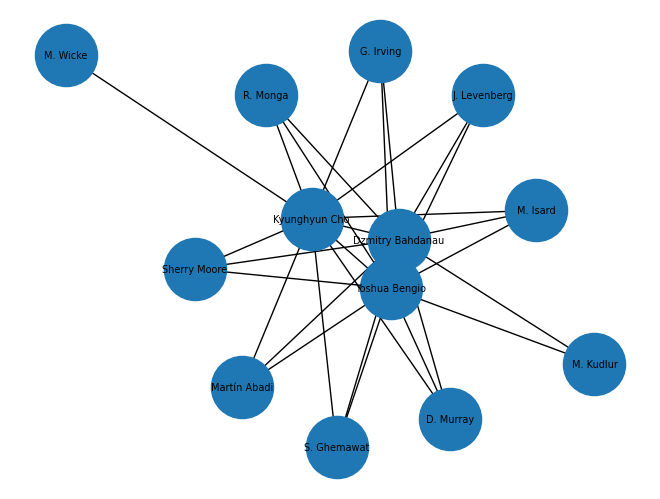

CSV exported successfully


In [60]:
observer = AgentObserver()
papers = observer.fetch_papers()

researchers = build_researchers(papers)

print("Columns:", researchers.columns)

if "publications_count" not in researchers.columns:
    raise Exception("Column missing — check build_researchers()")

profiler = AgentProfiler()
profiler.run(researchers)

save_database(researchers, papers)

matcher = AgentExpertiseMatcher()
embeddings, sim = matcher.run(researchers)

cluster = AgentCluster()
clustered = cluster.run(researchers, embeddings)

advisor = AgentCollabAdvisor()
collabs = advisor.run(clustered, sim)

print("Top Collaborations:")
display(collabs.head(10))

negotiator = AgentNegotiator()
final = negotiator.run(collabs)

print("Accepted Collaborations:")
display(final[final["decision"] == "ACCEPTED"].head(10))

plot_network(final)

final.to_csv("final_results.csv", index=False)
print("CSV exported successfully")

## Conclusion
This notebook demonstrates a complete Multi-Agent System using real-world data, semantic AI, clustering, collaboration optimization, and game theory.

In [61]:
final.to_csv("final_results.csv", index=False)